# Growth Funnel & Retention Analytics — Fashion E-commerce

**Myntra-inspired independent portfolio case study.** This notebook uses only the aggregate outputs generated by `analysis/build_metrics.py`; raw customer-level data is intentionally excluded from the repository.

### Business question
Do promo-acquired fashion buyers retain worse, and where should a growth team focus after first purchase?

### Key caution
This is **not Myntra proprietary data** and the clickstream is transaction-centered. The goal is to demonstrate product/growth analysis and disciplined interpretation, not publish Myntra benchmarks.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'analysis' / 'outputs').exists():
    ROOT = ROOT.parent
OUT = ROOT / 'analysis' / 'outputs'

D = json.loads((OUT / 'dashboard_data.json').read_text())
retention = pd.read_csv(OUT / 'promo_retention_curve.csv')
monthly = pd.read_csv(OUT / 'monthly_metrics.csv')
heat = pd.read_csv(OUT / 'cohort_retention_heatmap.csv')
print('Loaded aggregate outputs from:', OUT)

Matplotlib is building the font cache; this may take a moment.


Loaded aggregate outputs from: /mnt/data/myntra-growth-retention/analysis/outputs


## 1. Executive metrics

The first layer answers: how many customers, journeys and successful purchases are in the analysis, and how much repeat behavior exists?

In [2]:
core = D['core']
d30 = retention[retention.window_days.eq(30)]
d30_all = d30.retained.sum() / d30.buyers.sum()

summary = pd.DataFrame({
    'Metric': [
        'Registered customers', 'Journey sessions', 'Successful buyers',
        'Successful orders', 'Payment success', 'D30 repeat purchase',
        'Ever-repeat buyers', 'Average successful order value'
    ],
    'Value': [
        f"{core['registered_customers']:,}", f"{core['journey_sessions']:,}",
        f"{core['successful_buyers']:,}", f"{core['successful_transactions']:,}",
        f"{core['payment_success_rate']:.1%}", f"{d30_all:.1%}",
        f"{core['repeat_buyer_rate']:.1%}", f"{core['aov_source_units']:,.0f} source units"
    ]
})
summary

,Metric,Value
0,Registered customers,"100,000"
1,Journey sessions,"895,203"
2,Successful buyers,"50,242"
3,Successful orders,"815,964"
4,Payment success,95.7%
5,D30 repeat purchase,19.0%
6,Ever-repeat buyers,79.6%
7,Average successful order value,"550,266 source units"


## 2. Promo vs non-promo repeat purchase

A buyer is **promo-acquired** when `promo_amount > 0` on their first successful purchase. Retention is cumulative second-successful-purchase retention, with cohort maturity enforced for each window.

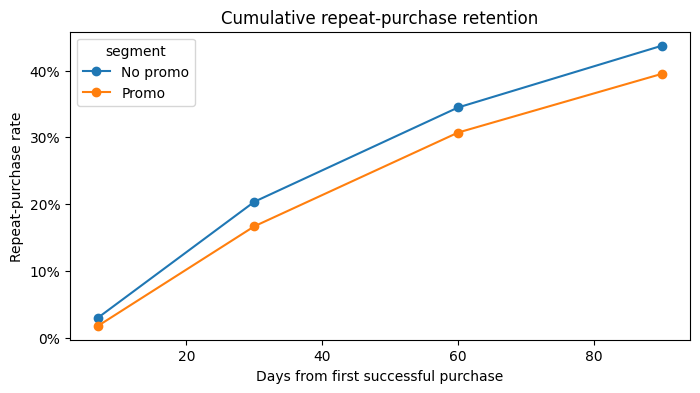

segment,No promo,Promo
window_days,,
7,3.0%,1.8%
30,20.3%,16.7%
60,34.5%,30.7%
90,43.7%,39.5%


In [3]:
pivot = retention.pivot(index='window_days', columns='segment', values='rate')
ax = pivot.plot(marker='o', figsize=(8,4))
ax.set_title('Cumulative repeat-purchase retention')
ax.set_xlabel('Days from first successful purchase')
ax.set_ylabel('Repeat-purchase rate')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
plt.show()
pivot.style.format('{:.1%}')

## 3. The result that changes the recommendation

The raw D30 comparison is tempting: promo-acquired customers appear meaningfully weaker. But the groups have different acquisition-month composition.

The project therefore standardizes promo and non-promo D30 rates **within first-purchase month**, using promo-cohort size as the weighting distribution.

In [4]:
p = D['promo_comparison']
comparison = pd.DataFrame({
    'Comparison': ['Raw', 'Acquisition-month standardized'],
    'No promo': [p['raw_no_promo_rate'], p['adjusted_no_promo_rate']],
    'Promo': [p['raw_promo_rate'], p['adjusted_promo_rate']],
    'Gap (pp)': [p['raw_gap_pp'], p['adjusted_gap_pp']]
})
comparison.style.format({'No promo':'{:.1%}', 'Promo':'{:.1%}', 'Gap (pp)':'{:.2f}'})

,Comparison,No promo,Promo,Gap (pp)
0,Raw,20.3%,16.7%,3.68
1,Acquisition-month standardized,17.2%,16.6%,0.54


**Interpretation:** the raw gap is about **3.7 percentage points (18.1% relative)**, but the standardized gap is only about **0.5 percentage points**. The raw chart is heavily affected by cohort mix. This does not prove promotions have zero effect; it means the observational data does not justify the claim that promotions cause weak retention.

**Product decision:** run a randomized post-purchase lifecycle/loyalty experiment instead of cutting acquisition promotions based on the raw correlation.

## 4. Monthly purchase-retention cohorts

This heatmap shows the share of each 2021 first-purchase cohort that makes at least one successful purchase in M0–M6. It is non-cumulative monthly activity retention, so later months can rise after an earlier dip.

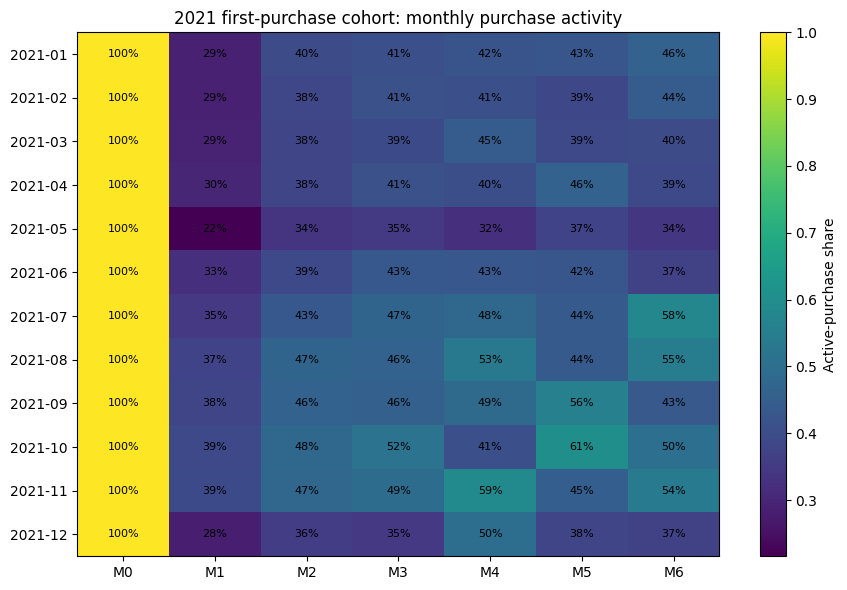

In [5]:
vals = heat[[f'm{i}' for i in range(7)]].to_numpy()
fig, ax = plt.subplots(figsize=(9,6))
im = ax.imshow(vals, aspect='auto')
ax.set_xticks(range(7), [f'M{i}' for i in range(7)])
ax.set_yticks(range(len(heat)), heat['cohort'])
ax.set_title('2021 first-purchase cohort: monthly purchase activity')
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f'{vals[i,j]:.0%}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Active-purchase share')
plt.tight_layout()
plt.show()

## 5. Revenue/value trend

`total_amount` is shown in the source dataset's monetary units; the project deliberately does not convert it to INR. The output is treated as a successful-order-value / GMV proxy rather than audited revenue.

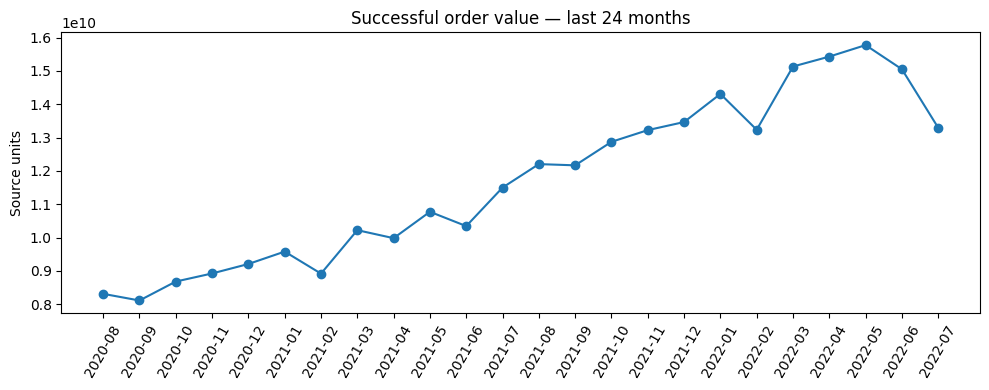

,category,share
0,Apparel,48.1%
1,Accessories,25.4%
2,Footwear,20.8%
3,Personal Care,5.4%
4,Free Items,0.2%
5,Sporting Goods,0.1%
6,Home,0.0%


In [6]:
m = monthly.tail(24).copy()
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(m['month'], m['gmv_source_units'], marker='o')
ax.set_title('Successful order value — last 24 months')
ax.set_ylabel('Source units')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

categories = pd.DataFrame(D['category_sales']).head(7)
categories[['category','share']].style.format({'share':'{:.1%}'})

## 6. Experiment sizing, not impact claiming

The dashboard includes an interactive relative-lift slider. At the default **18% relative lift** applied to the observed promo D30 baseline, the historical cohort implies roughly **533 incremental repeat buyers** and **~295M source units** of second-order value.

This is a scenario model for sizing a test. It is **not** a forecast and should never be written as “the recommendation will improve retention by 18%.”

In [7]:
lift = 0.18
baseline = p['raw_promo_rate']
inc_buyers = p['mature_promo_buyers'] * baseline * lift
inc_value = inc_buyers * p['promo_second_order_aov_source_units']
print(f'Promo D30 baseline: {baseline:.1%}')
print(f'18% relative-lift scenario: {baseline*(1+lift):.1%}')
print(f'Incremental repeat buyers: {inc_buyers:,.0f}')
print(f'Incremental 2nd-order value: {inc_value:,.0f} source units')

Promo D30 baseline: 16.7%
18% relative-lift scenario: 19.7%
Incremental repeat buyers: 533
Incremental 2nd-order value: 294,919,480 source units


## 7. What I would test next

1. **Accelerate purchase #2:** D7–D14 personalized category/wishlist reminder + loyalty milestone before D30 for first-time promo buyers.
2. **Use randomized holdouts:** primary metric = D30 second successful purchase; guardrails = AOV, discount cost per retained buyer, payment failure.
3. **Instrument referral:** invite/referrer linkage is absent, so referral conversion and K-factor cannot be measured yet.
4. **Improve acquisition attribution:** MOBILE/WEB is too coarse; add campaign, creative, cost and referrer data to optimize retained CAC.

The strongest part of this case study is not a dramatic uplift number. It is changing the conclusion when a better comparison shows the original story was confounded.